In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.metrics import classification_report, confusion_matrix


In [84]:
df0404 = pd.read_csv("../data/labeledAndAnomaly/no_plug/0404.csv")
df0712 = pd.read_csv("../data/labeledAndAnomaly/no_plug/0712.csv")
df1703 = pd.read_csv("../data/labeledAndAnomaly/no_plug/1703.csv")
df2906_1 = pd.read_csv("../data/labeledAndAnomaly/no_plug/2906-1.csv")
df3006_1 = pd.read_csv("../data/labeledAndAnomaly/no_plug/3006-1.csv")
df3006_2 = pd.read_csv("../data/labeledAndAnomaly/no_plug/3006-2.csv")

df1103 = pd.read_csv("../data/labeledAndAnomaly/partial_plug/1103.csv")
df1803 = pd.read_csv("../data/labeledAndAnomaly/partial_plug/1803.csv")
df2503 = pd.read_csv("../data/labeledAndAnomaly/partial_plug/2503.csv")
df2108_1 = pd.read_csv("../data/labeledAndAnomaly/partial_plug/2108-1.csv")


df0612_2 = pd.read_csv("../data/labeledAndAnomaly/plug/0612-2.csv")
df0612_3 = pd.read_csv("../data/labeledAndAnomaly/plug/0612-3.csv")
df0707_1 = pd.read_csv("../data/labeledAndAnomaly/plug/0707-1.csv")
df0707_2 = pd.read_csv("../data/labeledAndAnomaly/plug/0707-2.csv")
df0707_4 = pd.read_csv("../data/labeledAndAnomaly/plug/0707-4.csv")
df0709 = pd.read_csv("../data/labeledAndAnomaly/plug/0709.csv")
df1003 = pd.read_csv("../data/labeledAndAnomaly/plug/1003.csv")
df1112 = pd.read_csv("../data/labeledAndAnomaly/plug/1112.csv")
df1310_2 = pd.read_csv("../data/labeledAndAnomaly/plug/1310-2.csv")
df1310_3 = pd.read_csv("../data/labeledAndAnomaly/plug/1310-3.csv")
df1407_1 = pd.read_csv("../data/labeledAndAnomaly/plug/1407-1.csv")
df1407_2 = pd.read_csv("../data/labeledAndAnomaly/plug/1407-2.csv")
df1407_3 = pd.read_csv("../data/labeledAndAnomaly/plug/1407-3.csv")
df1407_4 = pd.read_csv("../data/labeledAndAnomaly/plug/1407-4.csv")
df1503 = pd.read_csv("../data/labeledAndAnomaly/plug/1503.csv")
df1811 = pd.read_csv("../data/labeledAndAnomaly/plug/1811.csv")
df2106_2 = pd.read_csv("../data/labeledAndAnomaly/plug/2106-2.csv")
df2108_2 = pd.read_csv("../data/labeledAndAnomaly/plug/2108-2.csv")
df2701 = pd.read_csv("../data/labeledAndAnomaly/plug/2701.csv")
df2906_2 = pd.read_csv("../data/labeledAndAnomaly/plug/2906-2.csv")
df2906_3 = pd.read_csv("../data/labeledAndAnomaly/plug/2906-3.csv")
df2906_4 = pd.read_csv("../data/labeledAndAnomaly/plug/2906-4.csv")
df3006_3 = pd.read_csv("../data/labeledAndAnomaly/plug/3006-3.csv")

In [85]:
no_plug_dfs = [df0404, df0712, df1703, df2906_1, df3006_1, df3006_2, df1103, df1803, df2503]
plug_dfs =  [df0612_2, df0612_3, df0707_1, df0707_2, df0707_4, df0709, df1003, df1112, df1310_2, df1310_3,
            df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2106_2, df2108_2, df2701, 
            df2906_2, df2906_3, df2906_4, df3006_3]
partial_plug_dfs = [df1103, df1803, df2503, df2108_1]

In [86]:

FINAL_FEATURES = [
    'rel_tot_dp_change', 
    'rel_ts_dp_change', 
    'rel_p_ts_dp_change', 
    'Relative_Ratio_Dev', 
    'anomaly_score'
]

WINDOW_SIZE = 60

In [87]:
def build_lstm_matrices(list_of_dfs, features, window_size=60):
    X_list = []
    y_list = []
    
    for df in list_of_dfs:
        data = df[features].values
        labels = df['label'].values
        
        for i in range(window_size, len(data)):
            window = data[i - window_size : i]
            target = labels[i]
            
            X_list.append(window)
            y_list.append(target)

    return np.array(X_list), np.array(y_list)

In [88]:
all_runs = no_plug_dfs + plug_dfs + partial_plug_dfs

X_all, y_all = build_lstm_matrices(all_runs, FINAL_FEATURES, window_size=WINDOW_SIZE)

print("--- Data Extraction Complete ---")
print(f"X_all Shape: {X_all.shape}")
print(f"y_all Shape: {y_all.shape}")

--- Data Extraction Complete ---
X_all Shape: (224779, 60, 5)
y_all Shape: (224779,)


In [89]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, 
    test_size=0.15, 
    random_state=42, 
    stratify=y_all
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, 
    test_size=0.1764, 
    random_state=42, 
    stratify=y_trainval
)

print("--- 70-15-15 Splitting ---")
print(f"Train Shape:      {X_train.shape}  (Labels: {len(y_train)})")
print(f"Validation Shape: {X_val.shape}  (Labels: {len(y_val)})")
print(f"Test Shape:       {X_test.shape}  (Labels: {len(y_test)})")

--- 70-15-15 Splitting ---
Train Shape:      (157358, 60, 5)  (Labels: 157358)
Validation Shape: (33704, 60, 5)  (Labels: 33704)
Test Shape:       (33717, 60, 5)  (Labels: 33717)


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

BATCH_SIZE = 128

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print("\n--- DataLoaders Ready ---")
print(f"Training Batches:   {len(train_loader)}")
print(f"Validation Batches: {len(val_loader)}")
print(f"Test Batches:       {len(test_loader)}")


--- DataLoaders Ready ---
Training Batches:   1230
Validation Batches: 264
Test Batches:       264


In [91]:
BATCH_SIZE = 128

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data is ready! Number of training batches per epoch: {len(train_loader)}")

Data is ready! Number of training batches per epoch: 1230


In [92]:
class HydraulicLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes):
        super(HydraulicLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # The Recurrent Layer
        # batch_first=True tells PyTorch our data format is (Batch, TimeSteps, Features)
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )
        
        # The Final Classifier Output Layer
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        # 1. Initialize hidden (h0) and cell (c0) states with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # 2. Forward pass through LSTM layer
        # out shape: (Batch Size, 60 Time Steps, Hidden Dimension)
        out, _ = self.lstm(x, (h0, c0))
        
        # 3. We only care about the hidden state of the VERY LAST time step (index -1)
        # This contains the summarized memory of the whole 60-second window
        last_time_step_output = out[:, -1, :]
        
        # 4. Pass that summary through our classifier to get the final 4 output scores
        logits = self.fc(last_time_step_output)
        return logits

In [93]:
INPUT_DIM = 5   
HIDDEN_DIM = 64  
NUM_LAYERS = 2   
NUM_CLASSES = 4  

model = HydraulicLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES)

criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print(model)

HydraulicLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)


In [ ]:
device = torch.device('cpu')
model = model.to(device)

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, max_epochs=20, patience=4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_epoch = 0
    
    print(f"Adaptive Training Loop started on: {device}\n")
    
    for epoch in range(max_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        
        # --- TRAINING MODE ---
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        
        # Create a dynamic text-based progress bar for training batches
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{max_epochs:02d} [Train] (LR: {current_lr:.6f})", leave=True)
        
        for batch_X, batch_y in train_bar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += batch_y.size(0)
            correct_train += (predicted == batch_y).sum().item()
            
            batch_acc = (predicted == batch_y).sum().item() / batch_y.size(0)
            train_bar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{batch_acc*100:.1f}%"})
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        # --- VALIDATION MODE ---
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        
        # Progress bar for validation batches
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{max_epochs:02d} [Valid]", leave=False)
        
        with torch.no_grad():
            for batch_X, batch_y in val_bar:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += batch_y.size(0)
                correct_val += (predicted == batch_y).sum().item()
                
                val_bar.set_postfix({'loss': f"{loss.item():.4f}"})
                
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = correct_val / total_val
        
        # Print final epoch summary statement
        print(f"✨ Epoch [{epoch+1:02d}/{max_epochs:02d}] Summary:")
        print(f"   [TRAIN] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc*100:.2f}%")
        print(f"   [VALID] Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc*100:.2f}%")
        
        # Step the scheduler based on the validation loss
        scheduler.step(epoch_val_loss)
        
        # Check for model improvement
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(model.state_dict(), '../models/best_hydraulic_lstm.pth')
            print(f"   ⭐ New Best Val Loss! Weights saved to 'best_hydraulic_lstm.pth'")
        else:
            epochs_no_improve += 1
            print(f"   ⚠️ No improvement in val loss for {epochs_no_improve} epoch(s).")
            
        print("=" * 70)
        
        # Early Stopping barrier check
        if epochs_no_improve >= patience:
            print(f"\n🛑 Early Stopping Triggered! No improvement for {patience} epochs.")
            print(f"Best configuration at Epoch {best_epoch} with Val Loss: {best_val_loss:.4f}")
            break
            
    # Load the champion weights back into memory
    model.load_state_dict(torch.load('../models/best_hydraulic_lstm.pth'))
    print("\n🏆 Absolute best model configuration successfully re-loaded into memory!")
    return model

In [95]:
best_model = train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    max_epochs=100, 
    patience=15
)

Adaptive Training Loop started on: cpu



Epoch 01/100 [Train] (LR: 0.001000):   0%|          | 0/1230 [00:00<?, ?it/s]

Epoch 01/100 [Valid]:   0%|          | 0/264 [00:00<?, ?it/s]

✨ Epoch [01/100] Summary:
   [TRAIN] Loss: 0.6031 | Acc: 75.69%
   [VALID] Loss: 0.5091 | Acc: 79.19%
   ⭐ New Best Val Loss! Weights saved to 'best_hydraulic_lstm.pth'


Epoch 02/100 [Train] (LR: 0.001000):   0%|          | 0/1230 [00:00<?, ?it/s]

...

Epoch 99/100 [Valid]:   0%|          | 0/264 [00:00<?, ?it/s]

✨ Epoch [99/100] Summary:
   [TRAIN] Loss: 0.0306 | Acc: 98.77%
   [VALID] Loss: 0.0307 | Acc: 98.83%
   ⚠️ No improvement in val loss for 3 epoch(s).


Epoch 100/100 [Train] (LR: 0.000000):   0%|          | 0/1230 [00:00<?, ?it/s]

Epoch 100/100 [Valid]:   0%|          | 0/264 [00:00<?, ?it/s]

✨ Epoch [100/100] Summary:
   [TRAIN] Loss: 0.0306 | Acc: 98.78%
   [VALID] Loss: 0.0308 | Acc: 98.83%
   ⚠️ No improvement in val loss for 4 epoch(s).

🏆 Absolute best model configuration successfully re-loaded into memory!


In [96]:
best_model.eval()

test_predictions = []
test_true_labels = []

print("Running final evaluation on the hidden Test Set...")

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Move data to the active device (GPU/CPU)
        batch_X = batch_X.to(device)
        
        # Forward pass to get raw scores (logits)
        outputs = best_model(batch_X)
        
        # Get the index of the highest score (our predicted class)
        _, predicted = torch.max(outputs, 1)
        
        # Store predictions and true labels back on the CPU as numpy arrays
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(batch_y.numpy())

# Convert to numpy arrays for easy metric calculation
y_pred = np.array(test_predictions)
y_true = np.array(test_true_labels)

print(" Evaluation complete!")

Running final evaluation on the hidden Test Set...
 Evaluation complete!



================ FINAL TEST SET REPORT ================
                      precision    recall  f1-score   support

    Class 0: Healthy     0.9879    0.9983    0.9931     15079
  Class 1: Mild Plug     0.9811    0.9442    0.9623      4176
Class 2: Severe Plug     0.9927    0.9905    0.9916     12841
  Class 3: Full Plug     0.9593    0.9753    0.9673      1621

            accuracy                         0.9875     33717
           macro avg     0.9803    0.9771    0.9786     33717
        weighted avg     0.9875    0.9875    0.9875     33717



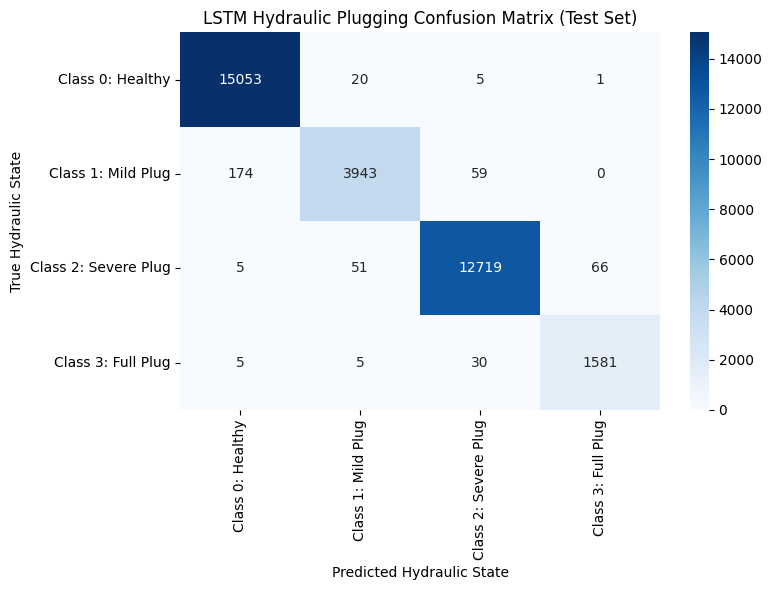

In [ ]:
# 1. Print the text-based classification report
target_names = ['Class 0: Healthy', 'Class 1: Mild Plug', 'Class 2: Severe Plug', 'Class 3: Full Plug']
print("\n================ FINAL TEST SET REPORT ================")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
print("=======================================================")

# 2. Build and plot a beautiful Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('LSTM Hydraulic Plugging Confusion Matrix (Test Set)')
plt.ylabel('True Hydraulic State')
plt.xlabel('Predicted Hydraulic State')
plt.tight_layout()
plt.show()

In [98]:
import copy
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure model is in evaluation mode
best_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Get the baseline accuracy from our unmodified test data
correct_baseline = 0
total_samples = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = best_model(batch_X)
        _, predicted = torch.max(outputs, 1)
        correct_baseline += (predicted.cpu() == batch_y).sum().item()
        total_samples += batch_y.size(0)

baseline_acc = correct_baseline / total_samples
print(f"Baseline Test Accuracy: {baseline_acc*100:.2f}%\n")

# Names of your 5 features (update these to match your exact column names)
feature_names = ['rel_tot_dp_change', 'rel_ts_dp_change', 'rel_p_ts_dp_change', 'Relative_Ratio_Dev', 'Anomaly_Score']
importance_scores = {}

# 2. Loop through each feature to evaluate its importance
# X_test_t shape is assumed to be: [Samples, Time_Steps (60), Features (5)]
for feat_idx, feat_name in enumerate(feature_names):
    # Create a deep copy of the test tensor so we don't permanently break it
    X_test_perturbed = copy.deepcopy(X_test_t)
    
    # Extract the data for just this specific feature across all samples and time steps
    # Shape becomes: (num_samples, 60)
    feat_data = X_test_perturbed[:, :, feat_idx].numpy()
    
    # Flatten, scramble the row order randomly, and reshape it back
    num_samples = feat_data.shape[0]
    shuffled_indices = np.random.permutation(num_samples)
    feat_data_shuffled = feat_data[shuffled_indices, :]
    
    # Shove the scrambled data back into our copied tensor
    X_test_perturbed[:, :, feat_idx] = torch.tensor(feat_data_shuffled, dtype=torch.float32)
    
    # Create a temporary loader for this corrupted dataset
    perturbed_dataset = torch.utils.data.TensorDataset(X_test_perturbed, y_test_t)
    perturbed_loader = torch.utils.data.DataLoader(perturbed_dataset, batch_size=128, shuffle=False)
    
    # Evaluate performance on the corrupted data
    correct_perturbed = 0
    with torch.no_grad():
        for batch_X, batch_y in perturbed_loader:
            batch_X = batch_X.to(device)
            outputs = best_model(batch_X)
            _, predicted = torch.max(outputs, 1)
            correct_perturbed += (predicted.cpu() == batch_y).sum().item()
            
    perturbed_acc = correct_perturbed / total_samples
    
    # Importance value is the absolute drop in accuracy
    accuracy_drop = baseline_acc - perturbed_acc
    importance_scores[feat_name] = accuracy_drop
    print(f"Scrambling '{feat_name}' -> New Acc: {perturbed_acc*100:.2f}% | Drop: {accuracy_drop*100:.2f}%")

Baseline Test Accuracy: 98.75%

Scrambling 'rel_tot_dp_change' -> New Acc: 56.96% | Drop: 41.79%
Scrambling 'rel_ts_dp_change' -> New Acc: 68.11% | Drop: 30.64%
Scrambling 'rel_p_ts_dp_change' -> New Acc: 85.43% | Drop: 13.32%
Scrambling 'Relative_Ratio_Dev' -> New Acc: 55.61% | Drop: 43.14%
Scrambling 'Anomaly_Score' -> New Acc: 55.83% | Drop: 42.92%


/var/folders/mn/hmhwf_5919qf62p9d6fjr1cw0000gn/T/ipykernel_61429/3418874953.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


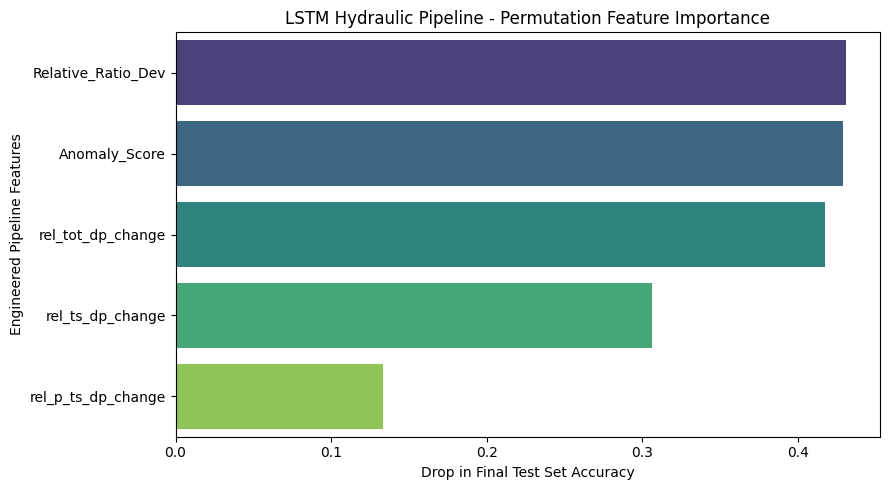

In [99]:
# Convert dictionary to a sorted DataFrame
df_importance = pd.DataFrame(list(importance_scores.items()), columns=['Feature', 'Importance'])
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('LSTM Hydraulic Pipeline - Permutation Feature Importance')
plt.xlabel('Drop in Final Test Set Accuracy')
plt.ylabel('Engineered Pipeline Features')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [100]:
import time

def get_live_probabilities(model, window_tensor, device):
    model.eval()
    with torch.no_grad():
        window_tensor = window_tensor.to(device)
        logits = model(window_tensor)
        # Convert raw scores to percentages summing to 1
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]
    return probabilities  # Returns array: [P(Healthy), P(Mild), P(Severe), P(Full)]

In [101]:
import numpy as np

class PlugETAEstimator:
    def __init__(self, history_seconds=120, smoothing_alpha=0.15):
            self.history_seconds = history_seconds
            self.smoothing_alpha = smoothing_alpha  # Lower = smoother/more inertia; Higher = faster reacting
            
            self.esi_history = []
            self.timestamps = []
            self.previous_filtered_eta = None
            self.is_lached_active = False
        
    def update_and_estimate_eta(self, probabilities):
        current_time = time.time()
        
        # 1. Expected State Index Calculation
        esi = (probabilities[0] * 0.0 + 
               probabilities[1] * 1.0 + 
               probabilities[2] * 2.0 + 
               probabilities[3] * 3.0)
        
        self.esi_history.append(esi)
        self.timestamps.append(current_time)
        
        if len(self.esi_history) > self.history_seconds:
            self.esi_history.pop(0)
            self.timestamps.pop(0)
            
        if len(self.esi_history) < 30:
            return "Calibrating Tracker..."
            
        # 2. Linear Regression over the entire memory window
        x = np.array(self.timestamps) - self.timestamps[0]
        y = np.array(self.esi_history)
        slope, _ = np.polyfit(x, y, 1)
        
        # 3. State Latching Logic
        # If ESI crosses 0.5, we latch into "Active Alarm Tracking Mode"
        if esi > 0.5:
            self.is_lached_active = True
        # Only unlatch if system falls completely back to pristine health
        elif esi < 0.15:
            self.is_lached_active = False
            self.previous_filtered_eta = None
            
        if not self.is_lached_active:
            if esi >= 2.95:
                return "0.0 Minutes (System Fully Plugged)"
            return "System Operating Normally"
            
        # 4. Calculate Raw ETA
        remaining_distance = 3.0 - esi
        if remaining_distance <= 0 or esi >= 2.95:
            return "0.0 Minutes (System Fully Plugged)"
            
        # Handle zero/negative slopes during active tracking
        if slope <= 0.00005:
            # If tracking is latched but slope went flat, we tick down by real elapsed time
            if self.previous_filtered_eta is not None:
                raw_eta = self.previous_filtered_eta - (1.0 / 60.0) # Subtract 1 second in minutes
            else:
                return "Plugging detected (System Stable/Slow Progression)"
        else:
            raw_eta = (remaining_distance / slope) / 60.0
            
        # 5. Industrial Smoothing (Alpha-Beta Filtering)
        if self.previous_filtered_eta is None:
            # Initial anchor point
            filtered_eta = raw_eta
        else:
            # Apply exponential smoothing to prevent jitter
            filtered_eta = (self.smoothing_alpha * raw_eta) + ((1.0 - self.smoothing_alpha) * self.previous_filtered_eta)
            
            # Monotonic Safety Guard: Do not allow the countdown to climb wildly due to a momentary dip
            if filtered_eta > self.previous_filtered_eta + 0.1 and slope < 0.001:
                filtered_eta = self.previous_filtered_eta - (1.0 / 60.0)
                
        # Bound constraints
        if filtered_eta < 0:
            filtered_eta = 0.0
            
        self.previous_filtered_eta = filtered_eta
        
        if filtered_eta > 120:
            return f"ETA to Full Plug: >2 hours (Current ESI: {esi:.2f})"
            
        return f"ETA to Full Plug: {filtered_eta:.1f} minutes"

In [ ]:
import numpy as np
import torch

# 1. Sort by time to guarantee strict chronological order for streaming
df1003_sorted = df1003.sort_values(by='run_specific_time_s').reset_index(drop=True)

# 2. Define the exact 5 features your model expects

final_feature_cols = [
    'rel_tot_dp_change', 
    'rel_ts_dp_change', 
    'rel_p_ts_dp_change', 
    'Relative_Ratio_Dev', 
    'anomaly_score'
]

label_col = 'label'  # Your target column containing 0, 1, 2, 3

# 3. Slice into 60-second rolling windows
window_size = 60
X_windows = []
y_windows = []

# Extract raw numpy arrays for speed
feature_array = df1003_sorted[final_feature_cols].values
label_array = df1003_sorted[label_col].values

# Slide across the timeline second-by-second
for i in range(0, len(df1003_sorted) - window_size + 1):
    # Grab 60 continuous seconds of features
    window_x = feature_array[i : i + window_size]
    # Grab the label at the very last second of that window
    window_y = label_array[i + window_size - 1]
    
    X_windows.append(window_x)
    y_windows.append(window_y)

# Convert to final numpy arrays for the simulator
X_single_run = np.array(X_windows)
y_single_run = np.array(y_windows)

print("--- Step 1: Pre-Calculated Run Ready ---")
print(f"X_single_run Shape: {X_single_run.shape} -> [{X_single_run.shape[0]} windows, 60 seconds, 5 features]")
print(f"y_single_run Shape: {y_single_run.shape} -> [{y_single_run.shape[0]} step-aligned true labels]")

--- Step 1: Pre-Calculated Run Ready ---
X_single_run Shape: (12813, 60, 5) -> [12813 windows, 60 seconds, 5 features]
y_single_run Shape: (12813,) -> [12813 step-aligned true labels]


In [103]:
import time
import numpy as np
import torch

# Initialize your ETA tracker (looking at the last 30 seconds of trend)
eta_tracker = PlugETAEstimator(history_seconds=120)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model.to(device)
best_model.eval()

print("🚀 Starting Live Pipeline Simulation...")
print("-" * 90)
print(f"{'Elapsed (s)':<12} | {'True State':<15} | {'Predicted State':<15} | {'ETA Output'}")
print("-" * 90)

# Dictionary to map class integers to readable strings
state_labels = {0: "Healthy", 1: "Mild Plug", 2: "Severe Plug", 3: "Full Plug"}

# Loop through the run chronologically, second by second
for t in range(len(X_single_run)):
    
    # 1. Simulate receiving the current 60-second window from the stream
    # Shape: [1, 60, 5] (Batch size of 1 for real-time inference)
    current_window = np.expand_dims(X_single_run[t], axis=0)
    current_window_t = torch.tensor(current_window, dtype=torch.float32).to(device)
    
    # 2. Get the ground truth for this exact second
    true_class = int(y_single_run[t])
    
    # 3. Pass through the LSTM
    with torch.no_grad():
        logits = best_model(current_window_t)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    
    pred_class = np.argmax(probs)
    
    # 4. Feed the probabilities into your ETA velocity engine
    eta_output = eta_tracker.update_and_estimate_eta(probs)
    
    # 5. Print a live readout every 10 seconds so it doesn't flood your screen
    if t % 10 == 0 or pred_class == 3:
        print(f"t = {t:<9} | {state_labels[true_class]:<15} | {state_labels[pred_class]:<15} | {eta_output}")
        
    # Optional: Uncomment the line below if you want to watch it update in real human time!
    # time.sleep(1) 

print("-" * 90)
print("🏁 Simulation Finished successfully!")

🚀 Starting Live Pipeline Simulation...
------------------------------------------------------------------------------------------
Elapsed (s)  | True State      | Predicted State | ETA Output
------------------------------------------------------------------------------------------
t = 0         | Healthy         | Healthy         | Calibrating Tracker...
t = 10        | Healthy         | Healthy         | Calibrating Tracker...
t = 20        | Healthy         | Healthy         | Calibrating Tracker...
t = 30        | Healthy         | Healthy         | System Operating Normally
t = 40        | Healthy         | Healthy         | System Operating Normally
t = 50        | Healthy         | Healthy         | System Operating Normally
t = 60        | Healthy         | Healthy         | System Operating Normally
t = 70        | Healthy         | Healthy         | System Operating Normally
t = 80        | Healthy         | Healthy         | System Operating Normally
t = 90        | Healthy 